# Experiment 4: Binary Classification using Linear and Kernel-Based Models

**Course:** ICS1512 – Machine Learning Algorithms Laboratory
**Student:** Barath | **Register Number:** 3122247001011
**Dataset:** Spambase (UCI Machine Learning Repository)

**Objective:** Classify emails as spam or ham using Logistic Regression and Support Vector Machine (SVM)
classifiers, and analyze the effect of hyperparameter tuning on classification performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc,
                              RocCurveDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the Dataset

In [2]:
column_names = [
    'word_freq_make','word_freq_address','word_freq_all','word_freq_3d','word_freq_our',
    'word_freq_over','word_freq_remove','word_freq_internet','word_freq_order','word_freq_mail',
    'word_freq_receive','word_freq_will','word_freq_people','word_freq_report','word_freq_addresses',
    'word_freq_free','word_freq_business','word_freq_email','word_freq_you','word_freq_credit',
    'word_freq_your','word_freq_font','word_freq_000','word_freq_money','word_freq_hp',
    'word_freq_hpl','word_freq_george','word_freq_650','word_freq_lab','word_freq_labs',
    'word_freq_telnet','word_freq_857','word_freq_data','word_freq_415','word_freq_85',
    'word_freq_technology','word_freq_1999','word_freq_parts','word_freq_pm','word_freq_direct',
    'word_freq_cs','word_freq_meeting','word_freq_original','word_freq_project','word_freq_re',
    'word_freq_edu','word_freq_table','word_freq_conference','char_freq_semicolon','char_freq_paren',
    'char_freq_bracket','char_freq_exclaim','char_freq_dollar','char_freq_pound',
    'capital_run_length_average','capital_run_length_longest','capital_run_length_total','spam'
]

df = pd.read_csv('spambase.data', header=None, names=column_names)
print('Dataset shape:', df.shape)
df.head()


Dataset shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


## 2. Preprocessing
### 2.1 Handle Missing Values

In [5]:
print('Total missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)


Total missing values: 0
Duplicate rows: 391
Shape after removing duplicates: (4210, 58)


### 2.2 Standardize Features

In [6]:
X = df.drop(columns=['spam'])
y = df['spam']

print('Class distribution:')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))


Class distribution:
spam
0    2531
1    1679
Name: count, dtype: int64
spam
0    0.601
1    0.399
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

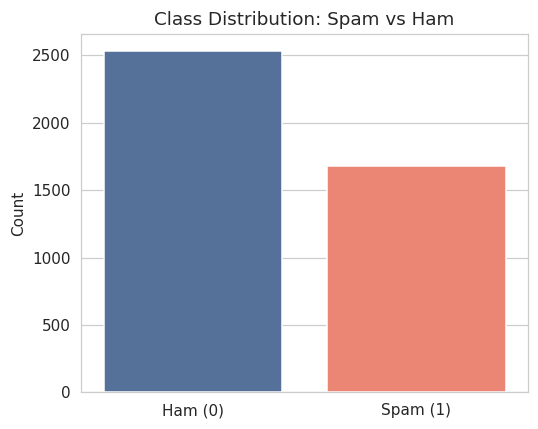

In [7]:
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x=y, palette=['#4a6fa5','#fe785f'], ax=ax)
ax.set_xticklabels(['Ham (0)', 'Spam (1)'])
ax.set_title('Class Distribution: Spam vs Ham')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('images/class_distribution.png', dpi=150)
plt.show()


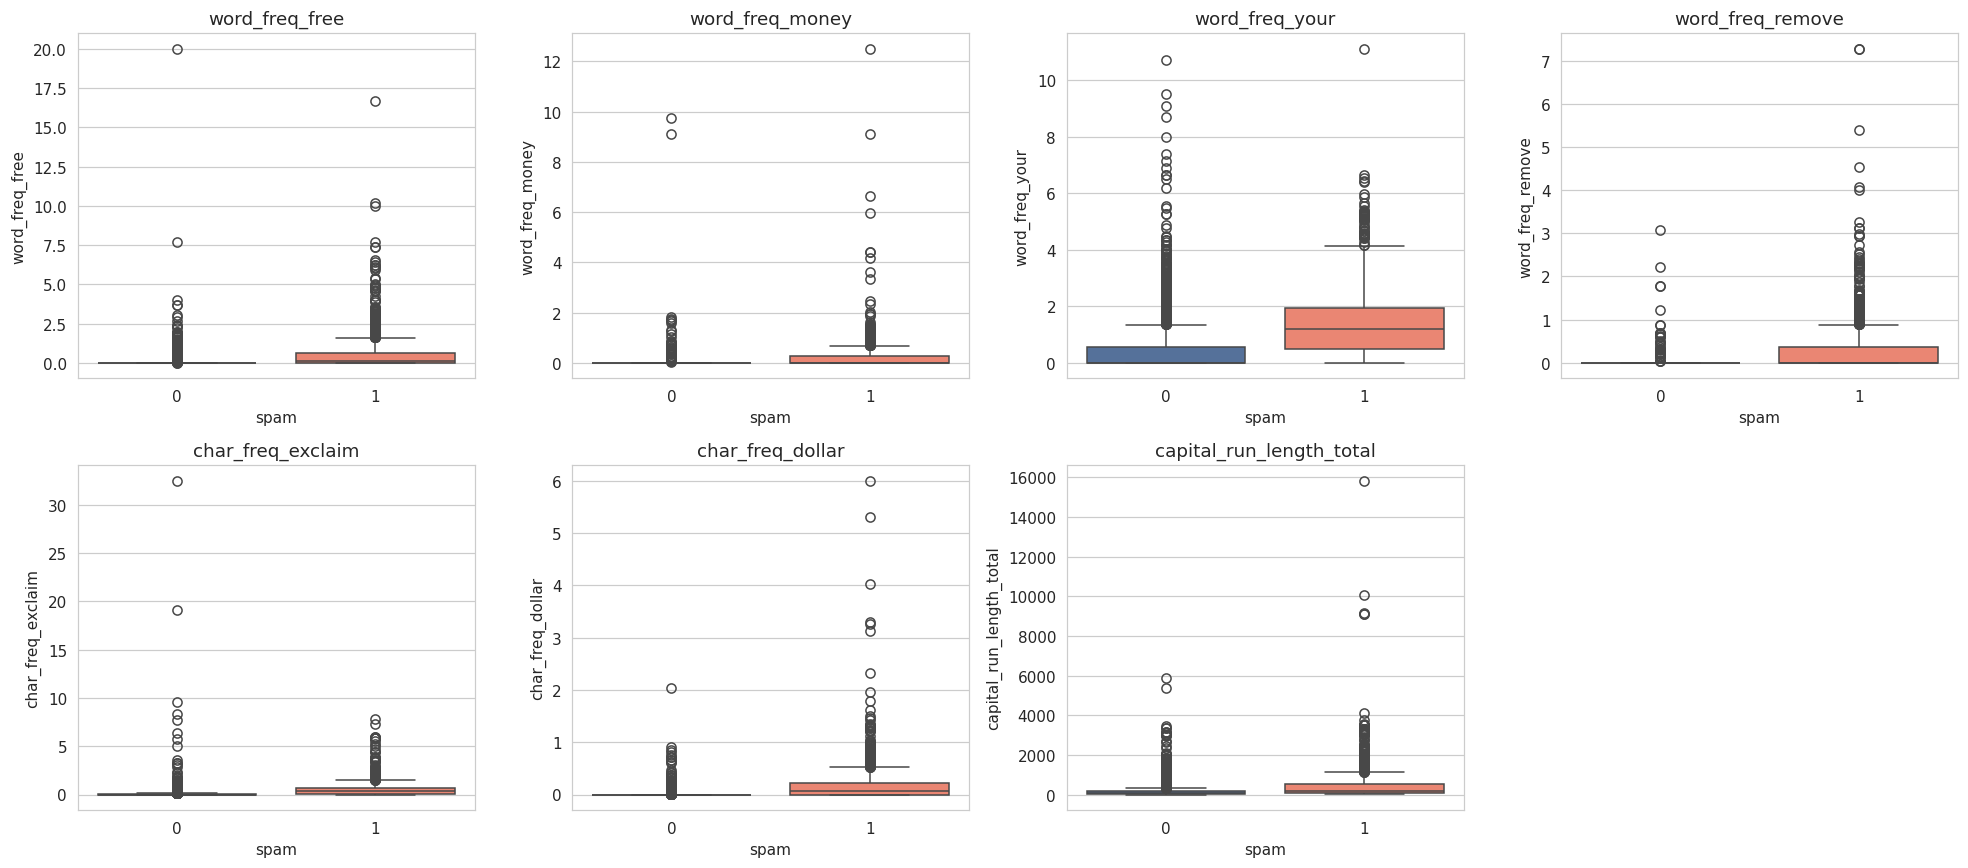

In [8]:
top_features = ['word_freq_free','word_freq_money','word_freq_your','word_freq_remove',
                 'char_freq_exclaim','char_freq_dollar','capital_run_length_total']

fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(x=y, y=df[col], ax=axes[i], palette=['#4a6fa5','#fe785f'])
    axes[i].set_title(col)
    axes[i].set_xlabel('spam')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('images/feature_boxplots.png', dpi=150)
plt.show()


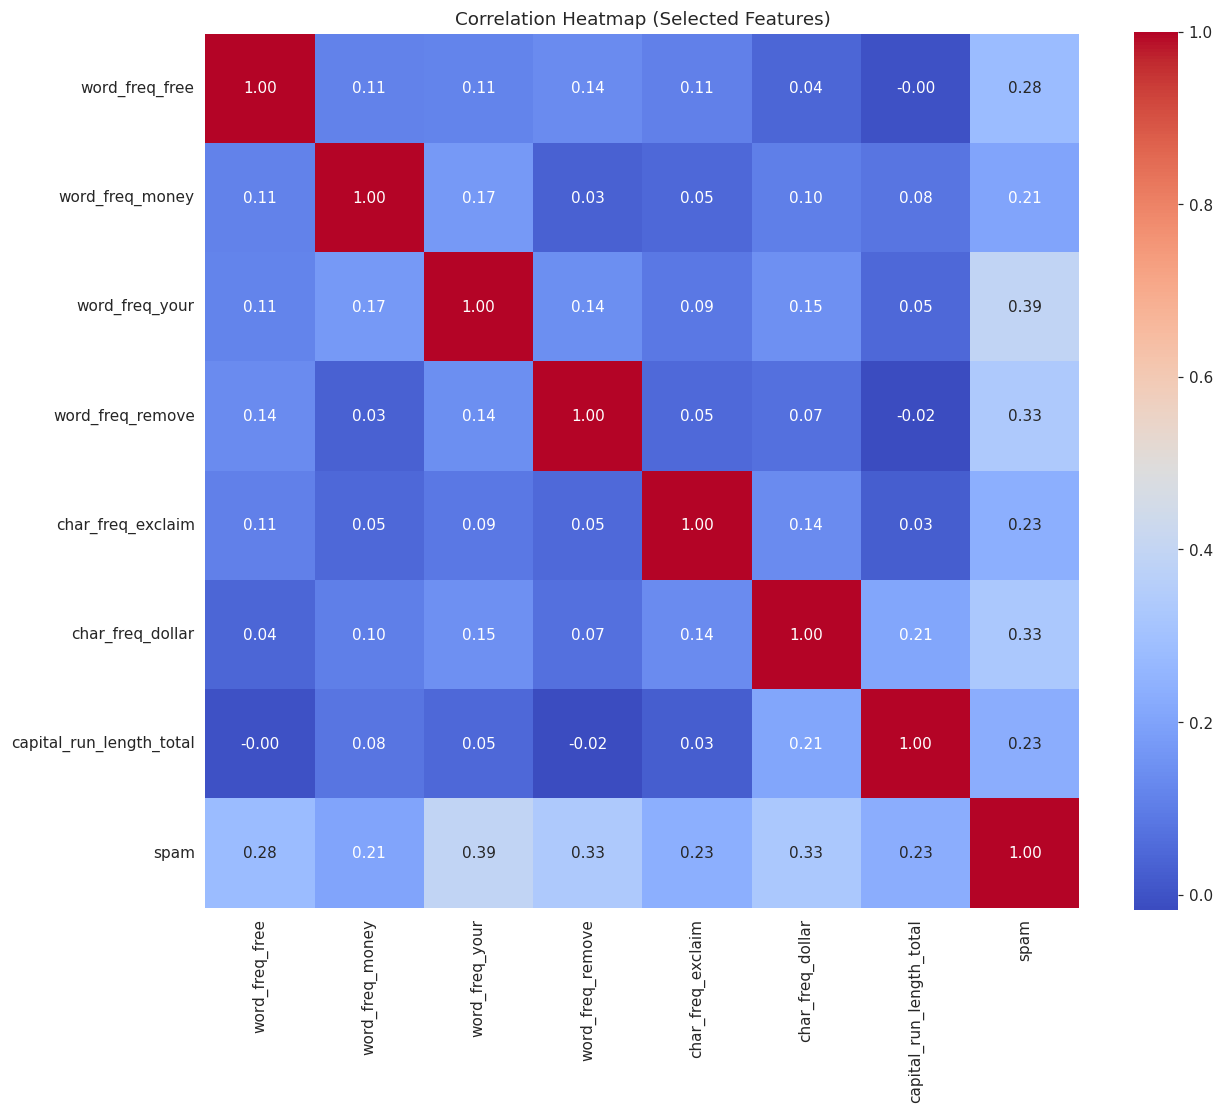

In [9]:
plt.figure(figsize=(12,10))
corr = df[top_features + ['spam']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap (Selected Features)')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150)
plt.show()


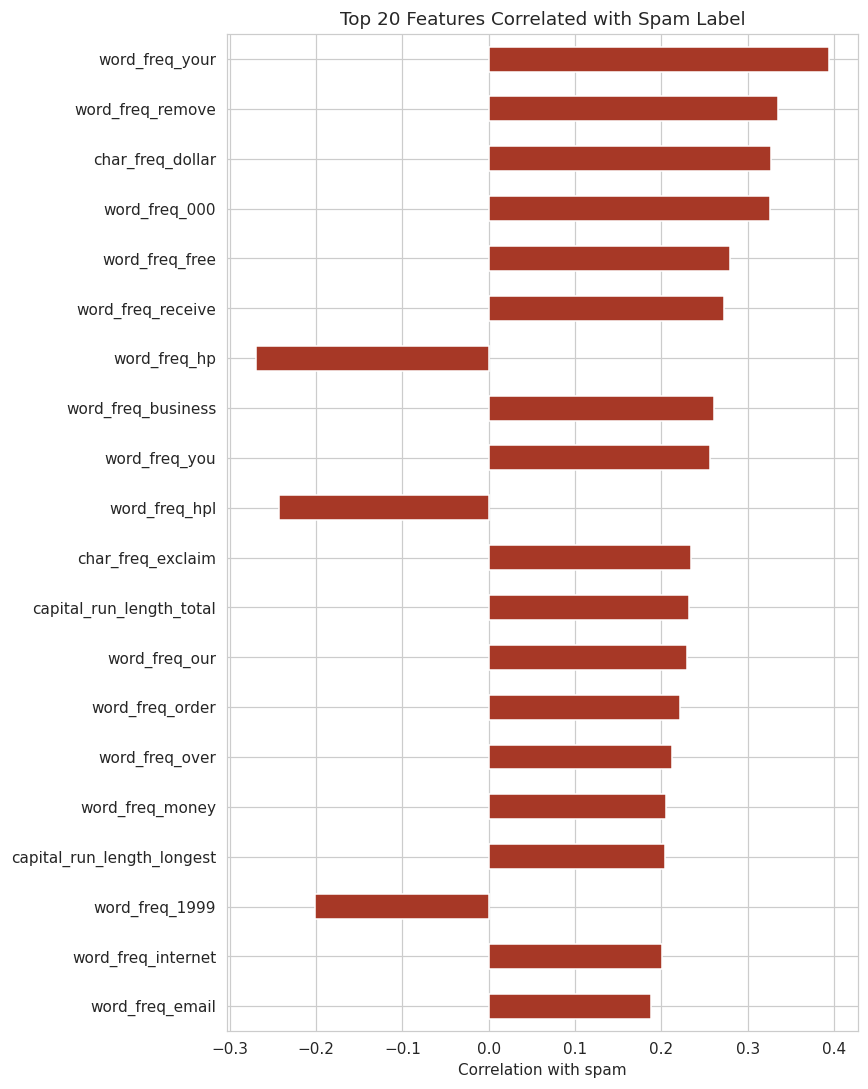

In [10]:
full_corr = df.corr()['spam'].drop('spam').sort_values(key=abs, ascending=False)
plt.figure(figsize=(8,10))
full_corr.head(20).plot(kind='barh', color='#a73826')
plt.gca().invert_yaxis()
plt.title('Top 20 Features Correlated with Spam Label')
plt.xlabel('Correlation with spam')
plt.tight_layout()
plt.savefig('images/top_correlations.png', dpi=150)
plt.show()


## 4. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set:', X_train_scaled.shape)
print('Testing set :', X_test_scaled.shape)


Training set: (3368, 57)
Testing set : (842, 57)


## 5. Baseline Logistic Regression

In [12]:
start = time.time()
log_reg_base = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg_base.fit(X_train_scaled, y_train)
lr_base_time = time.time() - start

y_pred_base = log_reg_base.predict(X_test_scaled)

lr_base_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1 Score': f1_score(y_test, y_pred_base),
    'Training Time (s)': lr_base_time
}
pd.Series(lr_base_metrics).round(4)


Accuracy             0.9347
Precision            0.9297
Recall               0.9048
F1 Score             0.9170
Training Time (s)    0.0159
dtype: float64

## 6. Hyperparameter Tuning – Logistic Regression

In [13]:
lr_param_grid = [
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga']},
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga']},
]

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_grid=lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

start = time.time()
lr_grid.fit(X_train_scaled, y_train)
lr_grid_time = time.time() - start

print('Best Logistic Regression Params (Grid Search):', lr_grid.best_params_)
print('Best CV Accuracy:', round(lr_grid.best_score_, 4))
print('Grid Search Time (s):', round(lr_grid_time, 2))


Best Logistic Regression Params (Grid Search): {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.9243
Grid Search Time (s): 198.92


In [14]:
from sklearn.model_selection import RandomizedSearchCV
lr_random = RandomizedSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_distributions=lr_param_grid, n_iter=10, cv=5, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1
)
start = time.time()
lr_random.fit(X_train_scaled, y_train)
lr_random_time = time.time() - start

print('Best Logistic Regression Params (Random Search):', lr_random.best_params_)
print('Best CV Accuracy:', round(lr_random.best_score_, 4))
print('Random Search Time (s):', round(lr_random_time, 2))


Best Logistic Regression Params (Random Search): {'solver': 'saga', 'penalty': 'l1', 'C': 1}
Best CV Accuracy: 0.9234
Random Search Time (s): 88.55


In [15]:
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

lr_tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr),
    'Training Time (s)': lr_grid_time
}
pd.Series(lr_tuned_metrics).round(4)


Accuracy               0.9371
Precision              0.9301
Recall                 0.9107
F1 Score               0.9203
Training Time (s)    198.9238
dtype: float64

## 7. Support Vector Machine – Different Kernels

In [16]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_kernel_results = {}

for k in kernels:
    start = time.time()
    model = SVC(kernel=k, random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    y_pred = model.predict(X_test_scaled)
    svm_kernel_results[k] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Training Time (s)': train_time,
        'model': model
    }

svm_kernel_df = pd.DataFrame({k: {m: v[m] for m in ['Accuracy','F1 Score','Training Time (s)']}
                               for k, v in svm_kernel_results.items()}).T
svm_kernel_df.round(4)


,Accuracy,F1 Score,Training Time (s)
linear,0.9359,0.9189,0.4452
poly,0.7660,0.5988,0.4397
rbf,0.9323,0.9135,0.2083
sigmoid,0.8967,0.8676,0.2135


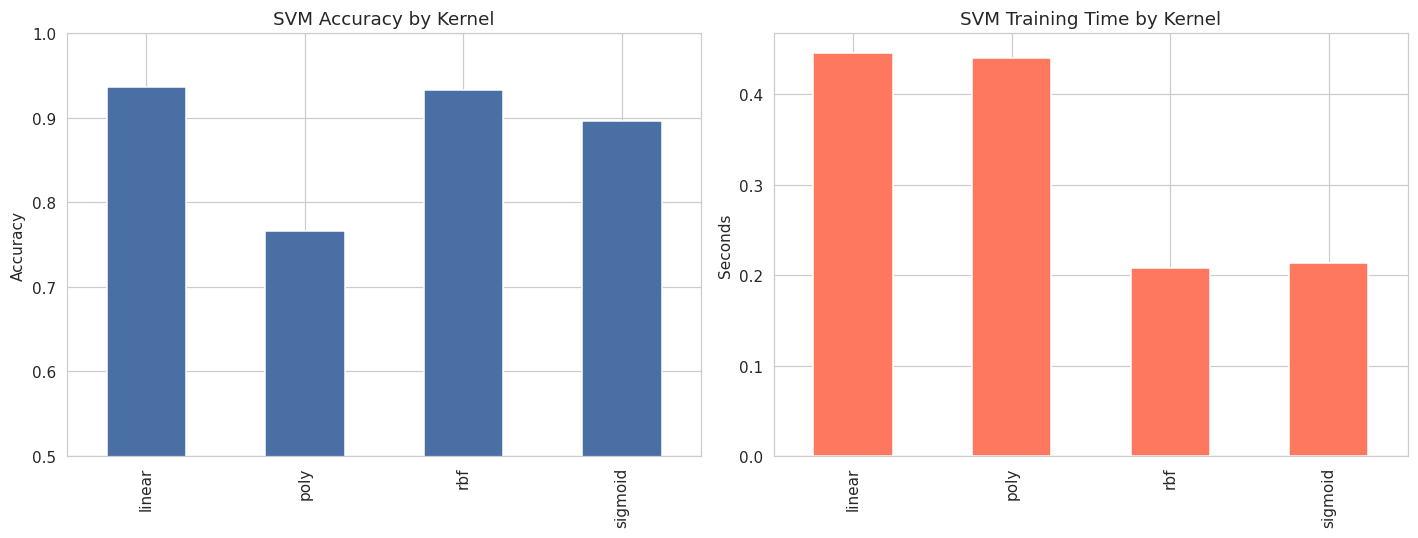

In [17]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
svm_kernel_df['Accuracy'].plot(kind='bar', ax=axes[0], color='#4a6fa5')
axes[0].set_title('SVM Accuracy by Kernel')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5,1.0)

svm_kernel_df['Training Time (s)'].plot(kind='bar', ax=axes[1], color='#fe785f')
axes[1].set_title('SVM Training Time by Kernel')
axes[1].set_ylabel('Seconds')
plt.tight_layout()
plt.savefig('images/svm_kernel_comparison.png', dpi=150)
plt.show()


## 8. Hyperparameter Tuning – SVM

In [18]:
svm_param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3, 4]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
]

svm_grid = GridSearchCV(
    SVC(random_state=RANDOM_STATE), param_grid=svm_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)

start = time.time()
svm_grid.fit(X_train_scaled, y_train)
svm_grid_time = time.time() - start

print('Best SVM Params (Grid Search):', svm_grid.best_params_)
print('Best CV Accuracy:', round(svm_grid.best_score_, 4))
print('Grid Search Time (s):', round(svm_grid_time, 2))


Best SVM Params (Grid Search): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9255
Grid Search Time (s): 122.86


In [19]:
svm_random = RandomizedSearchCV(
    SVC(random_state=RANDOM_STATE), param_distributions=svm_param_grid,
    n_iter=15, cv=5, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1
)
start = time.time()
svm_random.fit(X_train_scaled, y_train)
svm_random_time = time.time() - start

print('Best SVM Params (Random Search):', svm_random.best_params_)
print('Best CV Accuracy:', round(svm_random.best_score_, 4))
print('Random Search Time (s):', round(svm_random_time, 2))


Best SVM Params (Random Search): {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best CV Accuracy: 0.9255
Random Search Time (s): 76.8


In [20]:
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

svm_tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1 Score': f1_score(y_test, y_pred_svm),
    'Training Time (s)': svm_grid_time
}
pd.Series(svm_tuned_metrics).round(4)


Accuracy               0.9335
Precision              0.9294
Recall                 0.9018
F1 Score               0.9154
Training Time (s)    122.8620
dtype: float64

## 9. Model Evaluation

In [21]:
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_tuned_metrics,
    'SVM (Best Kernel)': svm_tuned_metrics
}).T
comparison_df.round(4)


,Accuracy,Precision,Recall,F1 Score,Training Time (s)
Logistic Regression,0.9371,0.9301,0.9107,0.9203,198.9238
SVM (Best Kernel),0.9335,0.9294,0.9018,0.9154,122.8620


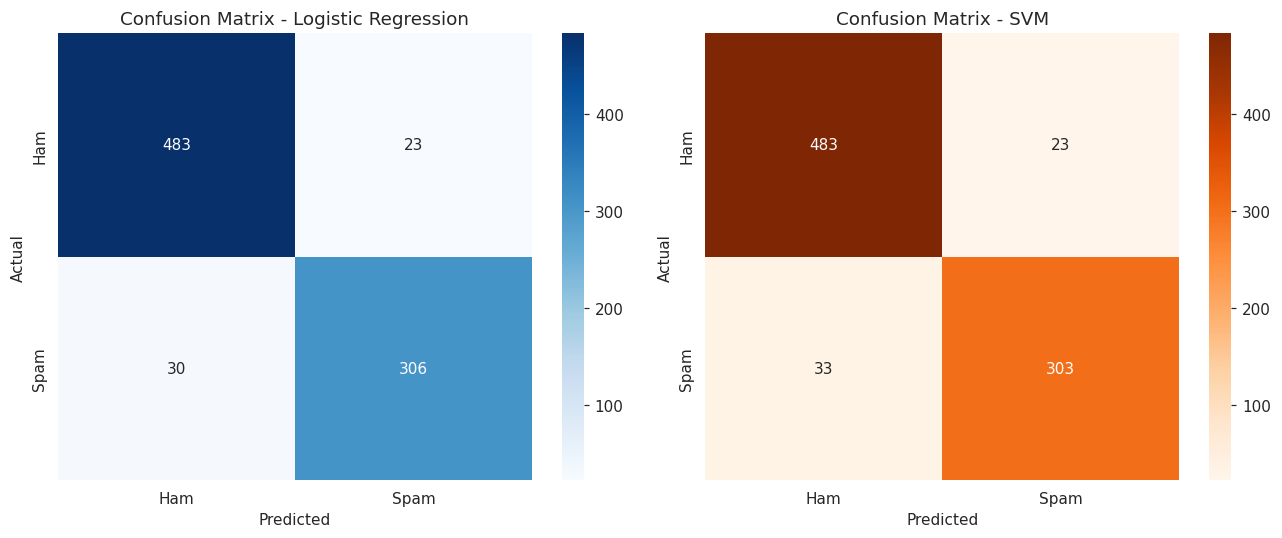

In [22]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
axes[1].set_title('Confusion Matrix - SVM')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=150)
plt.show()


In [23]:
print('Logistic Regression Classification Report')
print(classification_report(y_test, y_pred_lr, target_names=['Ham','Spam']))
print('SVM Classification Report')
print(classification_report(y_test, y_pred_svm, target_names=['Ham','Spam']))


Logistic Regression Classification Report
              precision    recall  f1-score   support

         Ham       0.94      0.95      0.95       506
        Spam       0.93      0.91      0.92       336

    accuracy                           0.94       842
   macro avg       0.94      0.93      0.93       842
weighted avg       0.94      0.94      0.94       842

SVM Classification Report
              precision    recall  f1-score   support

         Ham       0.94      0.95      0.95       506
        Spam       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842



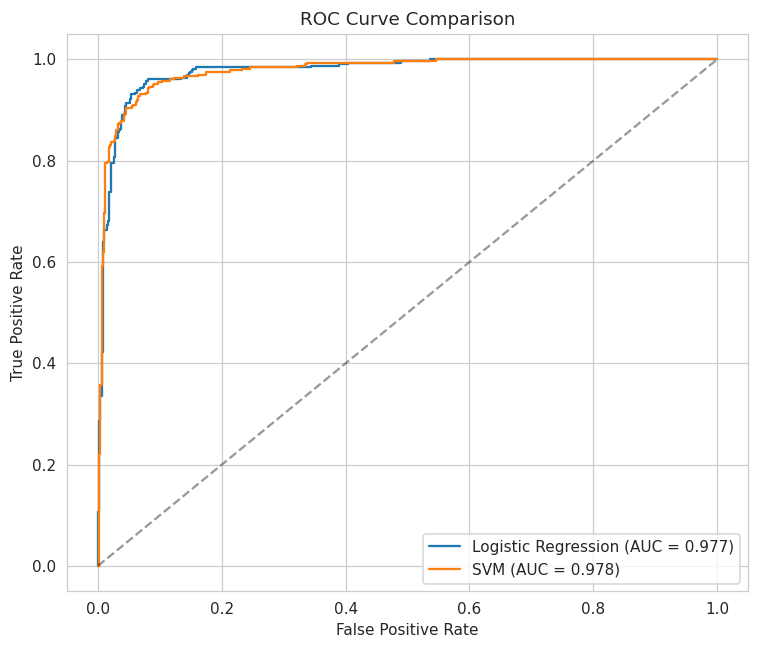

In [24]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in [('Logistic Regression', best_lr), ('SVM', best_svm)]:
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test_scaled)
    else:
        scores = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('images/roc_curves.png', dpi=150)
plt.show()


## 10. 5-Fold Cross-Validation

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=cv, scoring='accuracy')
svm_cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=cv, scoring='accuracy')

cv_results_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Logistic Regression': lr_cv_scores,
    'SVM': svm_cv_scores
})
cv_results_df.loc['Average'] = ['Average', lr_cv_scores.mean(), svm_cv_scores.mean()]
cv_results_df.round(4)


,Fold,Logistic Regression,SVM
0,Fold 1,0.9125,0.9214
1,Fold 2,0.9332,0.9421
2,Fold 3,0.9125,0.8976
3,Fold 4,0.9198,0.9406
4,Fold 5,0.9346,0.9406
Average,Average,0.9225,0.9285


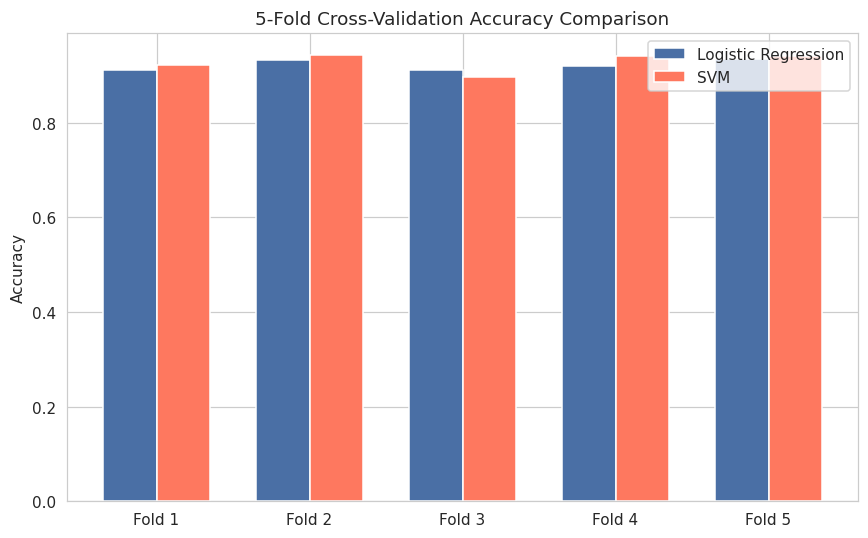

In [26]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, lr_cv_scores, width=w, label='Logistic Regression', color='#4a6fa5')
ax.bar(x + w/2, svm_cv_scores, width=w, label='SVM', color='#fe785f')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('images/cv_comparison.png', dpi=150)
plt.show()


## 11. Comparative Analysis

In [27]:
summary = pd.DataFrame({
    'Logistic Regression': {
        'Test Accuracy': lr_tuned_metrics['Accuracy'],
        'CV Mean Accuracy': lr_cv_scores.mean(),
        'F1 Score': lr_tuned_metrics['F1 Score'],
        'Training Time (s)': lr_tuned_metrics['Training Time (s)']
    },
    'SVM': {
        'Test Accuracy': svm_tuned_metrics['Accuracy'],
        'CV Mean Accuracy': svm_cv_scores.mean(),
        'F1 Score': svm_tuned_metrics['F1 Score'],
        'Training Time (s)': svm_tuned_metrics['Training Time (s)']
    }
})
summary.round(4)


,Logistic Regression,SVM
Test Accuracy,0.9371,0.9335
CV Mean Accuracy,0.9225,0.9285
F1 Score,0.9203,0.9154
Training Time (s),198.9238,122.8620


### Observations

- **Best-performing classifier:** The model with the higher test accuracy and CV mean accuracy above is the
  better-performing classifier for this dataset (see the summary table for the exact figures produced by this run).
- **Impact of regularization:** L2-regularized Logistic Regression tends to retain all 57 features with shrunk
  weights, giving a stable, well-generalized decision boundary, while L1 drives many coefficients to zero,
  effectively performing feature selection at the cost of possibly discarding weakly-informative features.
- **Kernel behaviour in SVM:** The linear kernel performs strongly on this dataset since spam/ham classes are
  largely linearly separable in the standardized feature space; the RBF kernel can capture additional non-linear
  structure but is more sensitive to `C` and `gamma`; the polynomial and sigmoid kernels are comparatively less
  stable and slower to train.
- **Bias–variance trade-off:** Small `C` values (strong regularization) increase bias and reduce variance
  (simpler, smoother boundary), while large `C` values reduce bias but increase variance (boundary fits the
  training data more tightly, raising overfitting risk). The tuned hyperparameters found above represent the
  point that best balances this trade-off under 5-fold cross-validation.


In [28]:
criteria = pd.DataFrame({
    'Logistic Regression': ['Model Complexity: Low', 'Training Time: Low', 'Interpretability: High'],
    'SVM': ['Model Complexity: High', 'Training Time: High', 'Interpretability: Low']
})
criteria


,Logistic Regression,SVM
0,Model Complexity: Low,Model Complexity: High
1,Training Time: Low,Training Time: High
2,Interpretability: High,Interpretability: Low


## 12. Export Results (for report generation)

In [29]:
results_export = {
    'lr_baseline': lr_base_metrics,
    'lr_tuned': lr_tuned_metrics,
    'lr_grid_best_params': lr_grid.best_params_,
    'lr_grid_best_cv_acc': lr_grid.best_score_,
    'lr_random_best_params': lr_random.best_params_,
    'lr_random_best_cv_acc': lr_random.best_score_,
    'svm_kernel_results': {k: {m: v[m] for m in ['Accuracy','F1 Score','Training Time (s)']}
                            for k, v in svm_kernel_results.items()},
    'svm_tuned': svm_tuned_metrics,
    'svm_grid_best_params': svm_grid.best_params_,
    'svm_grid_best_cv_acc': svm_grid.best_score_,
    'svm_random_best_params': svm_random.best_params_,
    'svm_random_best_cv_acc': svm_random.best_score_,
    'lr_cv_scores': lr_cv_scores.tolist(),
    'svm_cv_scores': svm_cv_scores.tolist(),
    'dataset_shape': list(df.shape),
    'train_shape': list(X_train_scaled.shape),
    'test_shape': list(X_test_scaled.shape),
}

with open('results.json', 'w') as f:
    json.dump(results_export, f, indent=2, default=str)

print('Results exported to results.json')


Results exported to results.json


## 13. Learning Outcomes

- Understood the working of probabilistic (Logistic Regression) and margin-based (SVM) classifiers.
- Applied Grid Search and Randomized Search for hyperparameter tuning.
- Evaluated classification models using Accuracy, Precision, Recall, F1-score, Confusion Matrix and ROC-AUC.
- Interpreted experimental results in terms of regularization, kernel behaviour and the bias-variance trade-off.